# MONAI MRI Classification: Essential Tremor vs Parkinson's Disease

**Binary classification of MRI PNG slices using EfficientNet-B0 + MONAI**

Pipeline:
1. Install & imports
2. Config (edit this block only)
3. Dataset preparation
4. Transforms
5. DataLoaders
6. Model setup
7. Two-phase training
8. Evaluation & plots
9. Save model

## 1. Install Dependencies

In [1]:
!pip install -q 'monai[all]' torchmetrics matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10

## 2. Imports

In [2]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

import monai
from monai.data import Dataset, DataLoader
from monai.transforms import (
    LoadImaged, EnsureChannelFirst, ScaleIntensity,
    Resize, RandFlip, RandRotate, RandZoom,
    RandGaussianNoise, RandAdjustContrast,
    ToTensor, Compose, Lambda
)
from monai.networks.nets import EfficientNetBN
from monai.losses import FocalLoss
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism

print(f"MONAI version : {monai.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-07 12:19:07.601428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775564347.825039      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775564347.885938      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775564348.388464      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775564348.388499      24 computation_placer.cc:1

MONAI version : 1.5.2
PyTorch version: 2.10.0+cu128
GPU available  : True
GPU name       : Tesla T4


## 3. Configuration — Edit This Block

Set your paths and hyperparameters here. Everything else adapts automatically.

In [3]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
# Option A: Two separate folders, one per class
#   DATA_ROOT/
#     ET/   *.png
#     PD/   *.png

# Option B: Flat folder with label encoded in filenames (see LABEL_FROM_FILENAME below)

DATA_ROOT   = "/kaggle/input/datasets/oovamoyo/preprocessed-dataset-2/processed"   # <-- change this
ET_DIR      = os.path.join(DATA_ROOT, "ET")  # folder for class 0
PD_DIR      = os.path.join(DATA_ROOT, "PD")  # folder for class 1
OUTPUT_DIR  = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── IMAGE ────────────────────────────────────────────────────────────────────
IMAGE_SIZE   = 224          # resize both axes to this
IN_CHANNELS  = 1            # 1 = grayscale MRI, 3 = RGB

# ─── TRAINING ─────────────────────────────────────────────────────────────────
SEED         = 42
VAL_SPLIT    = 0.15         # fraction of data for validation
TEST_SPLIT   = 0.15         # fraction of data for test
BATCH_SIZE   = 32
NUM_WORKERS  = 4

# Phase 1 — frozen backbone, warm up head
PHASE1_LR    = 1e-3
PHASE1_EPOCHS = 5

# Phase 2 — full fine-tune
PHASE2_LR    = 1e-4
PHASE2_EPOCHS = 20

# Loss
FOCAL_GAMMA  = 2.0          # 0 = cross-entropy, >0 = focal loss

# ─── LABELS ───────────────────────────────────────────────────────────────────
CLASS_NAMES  = ["ET", "PD"]  # index 0, 1

set_determinism(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 4. Build Data List

Scans the two class folders and creates a list of `{image, label}` dicts. 
Already assumes you've undersampled — just point to balanced folders.

In [4]:
def build_data_list(et_dir, pd_dir):
    """Collect all PNGs from two class directories."""
    et_files = sorted(glob.glob(os.path.join(et_dir, "**/*.png"), recursive=True) +
                      glob.glob(os.path.join(et_dir, "*.png")))
    pd_files = sorted(glob.glob(os.path.join(pd_dir, "**/*.png"), recursive=True) +
                      glob.glob(os.path.join(pd_dir, "*.png")))

    data = [{"image": f, "label": 0} for f in et_files] + \
           [{"image": f, "label": 1} for f in pd_files]

    random.shuffle(data)
    return data


all_data = build_data_list(ET_DIR, PD_DIR)

# ── Split: train / val / test ─────────────────────────────────────────────────
labels = [d["label"] for d in all_data]

train_val, test_data = train_test_split(
    all_data, test_size=TEST_SPLIT, stratify=labels, random_state=SEED)

train_val_labels = [d["label"] for d in train_val]
train_data, val_data = train_test_split(
    train_val, test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=train_val_labels, random_state=SEED)

print(f"Total  : {len(all_data):>6}  (ET={labels.count(0)}, PD={labels.count(1)})")
print(f"Train  : {len(train_data):>6}")
print(f"Val    : {len(val_data):>6}")
print(f"Test   : {len(test_data):>6}")

Total  :   7424  (ET=2386, PD=5038)
Train  :   5196
Val    :   1114
Test   :   1114


In [5]:
print(train_data[0])

{'image': '/kaggle/input/datasets/oovamoyo/preprocessed-dataset-2/processed/PD/МРТ_Газизов_ШХ_-_БП__IMG-0003-00020.png', 'label': 1}


## 5. Transforms

In [6]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Lambdad,
    ScaleIntensityd, ResizeD,
    RandFlipd, RandRotated, RandZoomd,
    RandAdjustContrastd, RandGaussianNoised,
    ToTensord
)

train_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    Lambdad(keys=["image"], func=lambda x: x[:IN_CHANNELS]),

    ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0),
    ResizeD(keys=["image"], spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),

    # ── Augmentations ──
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandRotated(keys=["image"], range_x=0.15, prob=0.5),
    RandZoomd(keys=["image"], min_zoom=0.9, max_zoom=1.1, prob=0.4),
    RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.5)),
    RandGaussianNoised(keys=["image"], prob=0.2, mean=0.0, std=0.01),

    ToTensord(keys=["image"]),
])
val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    Lambdad(keys=["image"], func=lambda x: x[:IN_CHANNELS]),

    ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0),
    ResizeD(keys=["image"], spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),

    ToTensord(keys=["image"]),
])

# ── Quick sanity check ────────────────────────────────────────────────────────
sample = train_transforms(train_data[0])

print(sample["image"].shape)
print(f"Value range: [{sample['image'].min():.3f}, {sample['image'].max():.3f}]")

torch.Size([1, 224, 224])
Value range: [0.000, 1.000]


## 6. Visualise a Batch (Sanity Check)

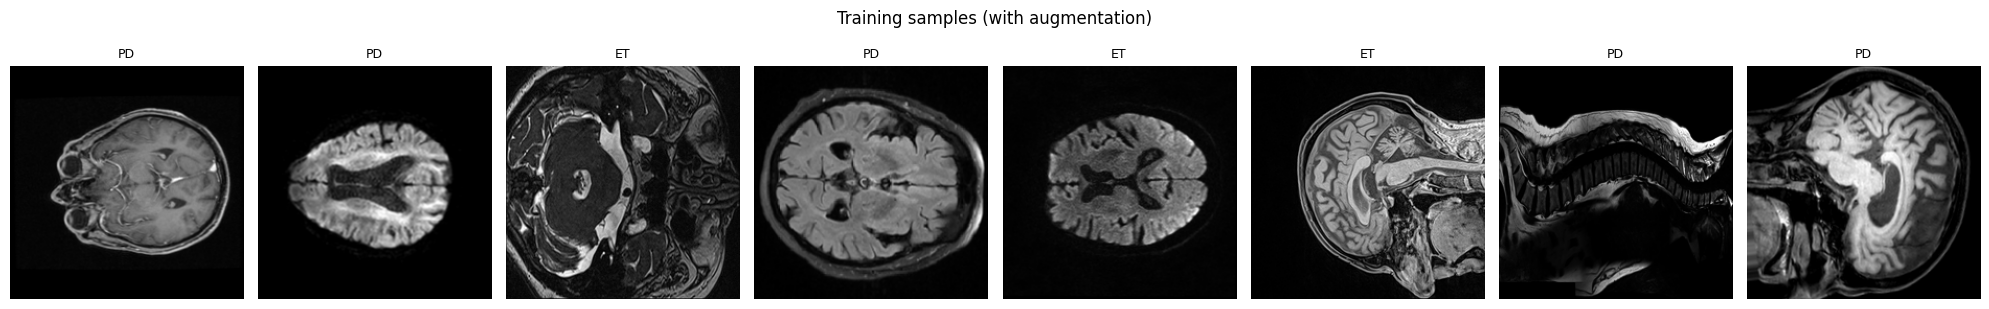

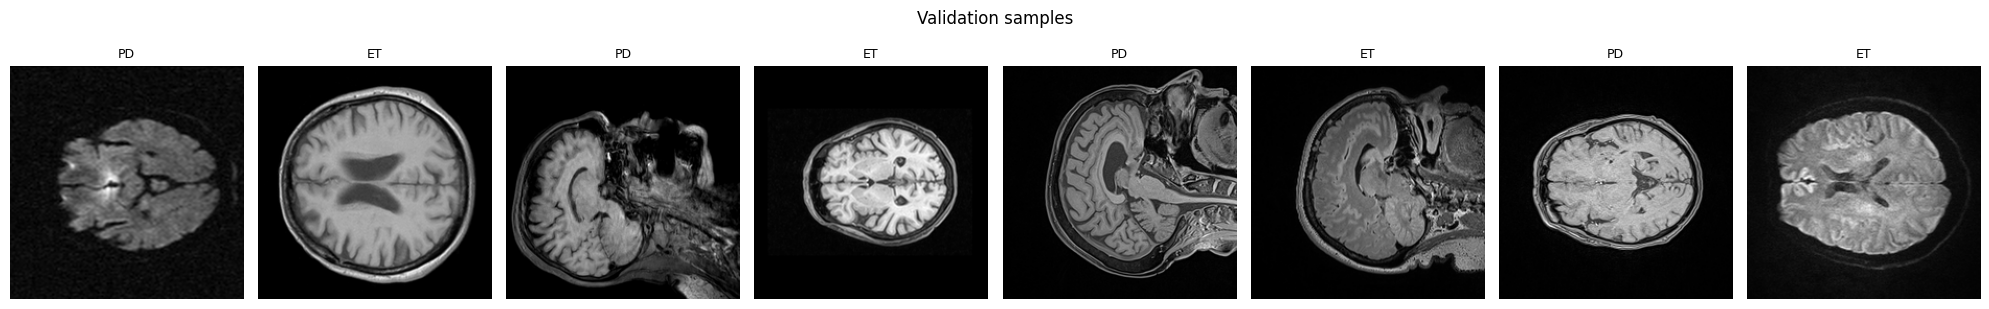

In [7]:
def show_samples(data_list, transforms, n=8, title="Samples"):
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    indices = random.sample(range(len(data_list)), n)

    for ax, idx in zip(axes, indices):
        item = data_list[idx]

        img_dict = transforms(item)        # ✅ dict output
        img = img_dict["image"]            # ✅ extract tensor

        label = item["label"]

        ax.imshow(img[0].numpy(), cmap="gray")
        ax.set_title(CLASS_NAMES[label], fontsize=9)
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

show_samples(train_data, train_transforms, title="Training samples (with augmentation)")
show_samples(val_data,   val_transforms,   title="Validation samples")


## 7. DataLoaders

In [8]:
train_ds = Dataset(data=train_data, transform=train_transforms)
val_ds   = Dataset(data=val_data,   transform=val_transforms)
test_ds  = Dataset(data=test_data,  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 163
Val   batches : 35
Test  batches : 35


## 8. Model

In [9]:
model = EfficientNetBN(
    model_name="efficientnet-b0",
    pretrained=True,          # ImageNet weights
    spatial_dims=2,           # 2-D PNG slices
    in_channels=IN_CHANNELS,  # 1 = grayscale
    num_classes=2,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 149MB/s]


Total params    : 4,009,534
Trainable params: 4,009,534


## 9. Loss & Metrics Helpers

In [10]:
loss_fn = FocalLoss(
    gamma=FOCAL_GAMMA,
    to_onehot_y=True
)
auc_metric = ROCAUCMetric()

import torch.nn.functional as F
def run_epoch(model, loader, optimizer=None, training=True):
    """Single train or eval epoch. Returns (avg_loss, auc)."""
    model.train() if training else model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs   = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE).long()

            logits = model(imgs)                              # (B, 2)
            # FocalLoss expects (B, C, ...) and label (B, ...)
            loss = loss_fn(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss  += loss.item()
            probs = torch.softmax(logits, dim=1)              # (B, 2)
            all_probs.append(probs.detach().cpu())
            all_labels.append(labels.detach().cpu())
    all_probs  = torch.cat(all_probs,  dim=0)  # (N, 2)
    all_labels = torch.cat(all_labels, dim=0)  # (N,)


    all_labels_onehot = F.one_hot(all_labels, num_classes=2).float()

    auc_metric(all_probs, all_labels_onehot)
    auc = auc_metric.aggregate().item()
    auc_metric.reset()

    avg_loss = total_loss / len(loader)
    return avg_loss, auc

## 10. Phase 1 — Frozen Backbone (Warm Up Head)

In [11]:
# Freeze everything except the classification head (_fc)
for name, param in model.named_parameters():
    param.requires_grad = ("_fc" in name)

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 — trainable params: {trainable_now:,}  (head only)")

optimizer_p1 = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR)

history_p1 = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_auc_p1 = 0.0

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train AUC':>9}  {'Val Loss':>8}  {'Val AUC':>7}")
print("-" * 55)

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(model, train_loader, optimizer_p1, training=True)
    vl_loss, vl_auc = run_epoch(model, val_loader,   training=False)

    history_p1["train_loss"].append(tr_loss)
    history_p1["val_loss"].append(vl_loss)
    history_p1["train_auc"].append(tr_auc)
    history_p1["val_auc"].append(vl_auc)

    if vl_auc > best_auc_p1:
        best_auc_p1 = vl_auc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_phase1.pth"))

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_auc:>9.4f}  {vl_loss:>8.4f}  {vl_auc:>7.4f}")

print(f"\nBest Phase-1 Val AUC: {best_auc_p1:.4f}")

Phase 1 — trainable params: 2,562  (head only)

Epoch  Train Loss  Train AUC  Val Loss  Val AUC
-------------------------------------------------------
    1      1.3053     0.5089    8.8336   0.4653
    2      1.1051     0.5364   13.1191   0.5026
    3      0.9843     0.5600    1.9144   0.4708
    4      0.9305     0.5754    0.7951   0.5489
    5      0.8445     0.5908    0.6474   0.5497

Best Phase-1 Val AUC: 0.5497


## 11. Phase 2 — Full Fine-Tuning

In [12]:
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 — trainable params: {trainable_now:,}  (full model)")

optimizer_p2 = Adam(model.parameters(), lr=PHASE2_LR)
scheduler    = CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6)

history_p2   = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_auc_p2  = 0.0
best_epoch   = 0

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train AUC':>9}  {'Val Loss':>8}  {'Val AUC':>7}  {'LR':>9}")
print("-" * 65)

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(model, train_loader, optimizer_p2, training=True)
    vl_loss, vl_auc = run_epoch(model, val_loader,   training=False)
    current_lr      = scheduler.get_last_lr()[0]

    history_p2["train_loss"].append(tr_loss)
    history_p2["val_loss"].append(vl_loss)
    history_p2["train_auc"].append(tr_auc)
    history_p2["val_auc"].append(vl_auc)

    if vl_auc > best_auc_p2:
        best_auc_p2 = vl_auc
        best_epoch  = epoch
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pth"))

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_auc:>9.4f}  {vl_loss:>8.4f}  {vl_auc:>7.4f}  {current_lr:>9.2e}")
    scheduler.step()

print(f"\nBest Phase-2 Val AUC: {best_auc_p2:.4f} at epoch {best_epoch}")

Phase 2 — trainable params: 4,009,534  (full model)

Epoch  Train Loss  Train AUC  Val Loss  Val AUC         LR
-----------------------------------------------------------------
    1      0.6594     0.6630    0.2811   0.7848   1.00e-04
    2      0.4192     0.7704    0.2642   0.8350   9.94e-05
    3      0.3056     0.8245    0.1748   0.8826   9.76e-05
    4      0.2349     0.8587    0.1496   0.9027   9.46e-05
    5      0.2003     0.8767    0.1360   0.9168   9.05e-05
    6      0.1707     0.8959    0.1132   0.9276   8.55e-05
    7      0.1521     0.9057    0.1025   0.9425   7.96e-05
    8      0.1380     0.9174    0.0846   0.9521   7.30e-05
    9      0.1211     0.9291    0.0857   0.9526   6.58e-05
   10      0.1157     0.9348    0.0809   0.9569   5.82e-05
   11      0.1070     0.9404    0.0720   0.9601   5.05e-05
   12      0.0975     0.9506    0.0711   0.9634   4.28e-05
   13      0.0940     0.9516    0.0674   0.9665   3.52e-05
   14      0.0891     0.9548    0.0654   0.9685   2.80e

## 12. Training Curves

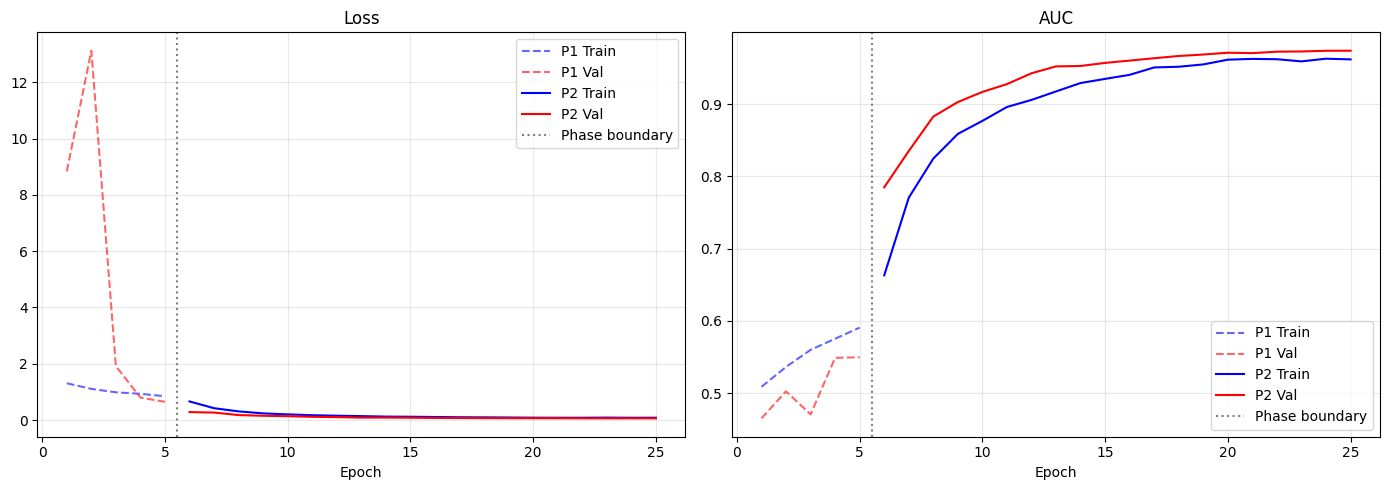

In [13]:
def plot_history(h1, h2):
    p1_epochs = len(h1["train_loss"])
    p2_epochs = len(h2["train_loss"])
    total     = p1_epochs + p2_epochs
    x1 = list(range(1, p1_epochs + 1))
    x2 = list(range(p1_epochs + 1, total + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, key, title in [
        (axes[0], "loss", "Loss"),
        (axes[1], "auc",  "AUC"),
    ]:
        ax.plot(x1, h1[f"train_{key}"], "b--", alpha=0.6, label="P1 Train")
        ax.plot(x1, h1[f"val_{key}"],   "r--", alpha=0.6, label="P1 Val")
        ax.plot(x2, h2[f"train_{key}"], "b-",             label="P2 Train")
        ax.plot(x2, h2[f"val_{key}"],   "r-",             label="P2 Val")
        ax.axvline(p1_epochs + 0.5, color="gray", linestyle=":", label="Phase boundary")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
    plt.show()

plot_history(history_p1, history_p2)

## 13. Test Set Evaluation

In [14]:
# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pth"), map_location=DEVICE))
model.eval()

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(DEVICE)
        labels = batch["label"].cpu().numpy()
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = probs.argmax(axis=1)

        all_probs.append(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)

all_probs  = np.vstack(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_auc = roc_auc_score(all_labels, all_probs[:, 1])
print(f"Test AUC: {test_auc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test AUC: 0.9796

              precision    recall  f1-score   support

          ET       0.87      0.92      0.90       358
          PD       0.96      0.94      0.95       756

    accuracy                           0.93      1114
   macro avg       0.92      0.93      0.92      1114
weighted avg       0.93      0.93      0.93      1114



## 14. Confusion Matrix & ROC Curve

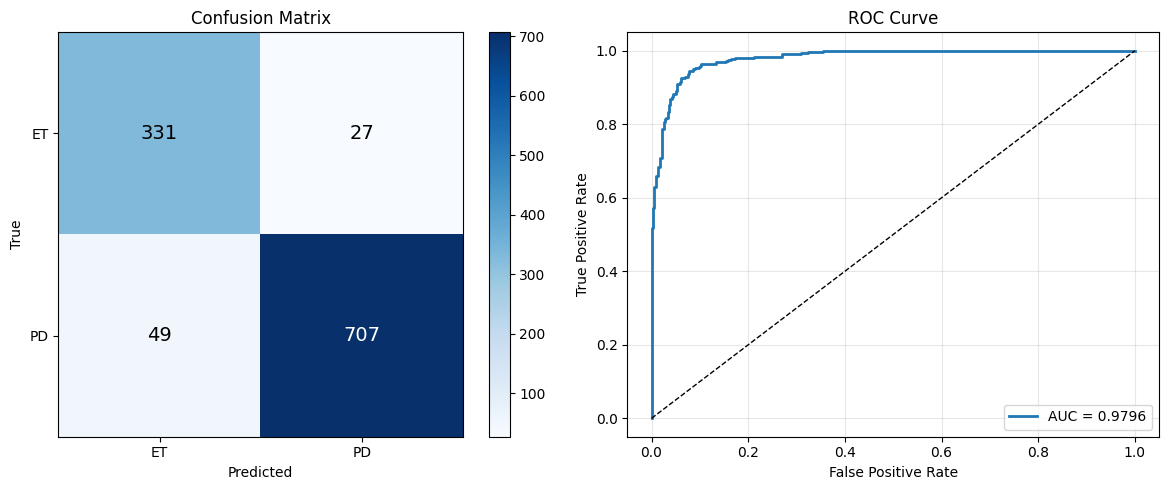

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
im = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im, ax=axes[0])

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {test_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "evaluation.png"), dpi=150)
plt.show()

## 15. Inference Speed Test

Confirms sub-second inference (thesis requirement).

In [16]:
import time

model.eval()
dummy = torch.randn(1, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy)

# Time 100 single-image inferences
times = []
with torch.no_grad():
    for _ in range(100):
        t0 = time.perf_counter()
        _  = model(dummy)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1000
std_ms  = np.std(times)  * 1000
print(f"Single-image inference: {mean_ms:.2f} ± {std_ms:.2f} ms")
print(f"Sub-second requirement: {'✓ PASS' if mean_ms < 1000 else '✗ FAIL'}")

Single-image inference: 8.60 ± 0.35 ms
Sub-second requirement: ✓ PASS


## 16. Save Final Model & Metadata

In [17]:
torch.save({
    "model_state_dict" : model.state_dict(),
    "model_name"       : "efficientnet-b0",
    "in_channels"      : IN_CHANNELS,
    "image_size"       : IMAGE_SIZE,
    "num_classes"      : 2,
    "class_names"      : CLASS_NAMES,
    "test_auc"         : test_auc,
    "best_val_auc_p2"  : best_auc_p2,
    "phase1_epochs"    : PHASE1_EPOCHS,
    "phase2_epochs"    : PHASE2_EPOCHS,
}, os.path.join(OUTPUT_DIR, "monai_efficientnet_b0_final.pth"))

print("Saved: monai_efficientnet_b0_final.pth")
print(f"\nSummary")
print(f"  Best Val AUC : {best_auc_p2:.4f}")
print(f"  Test AUC     : {test_auc:.4f}")
print(f"  Inference    : {mean_ms:.2f} ms")

Saved: monai_efficientnet_b0_final.pth

Summary
  Best Val AUC : 0.9738
  Test AUC     : 0.9796
  Inference    : 8.60 ms


## 17. (Optional) GradCAM Visualisation

Shows which regions the model is attending to — useful for thesis interpretability section.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


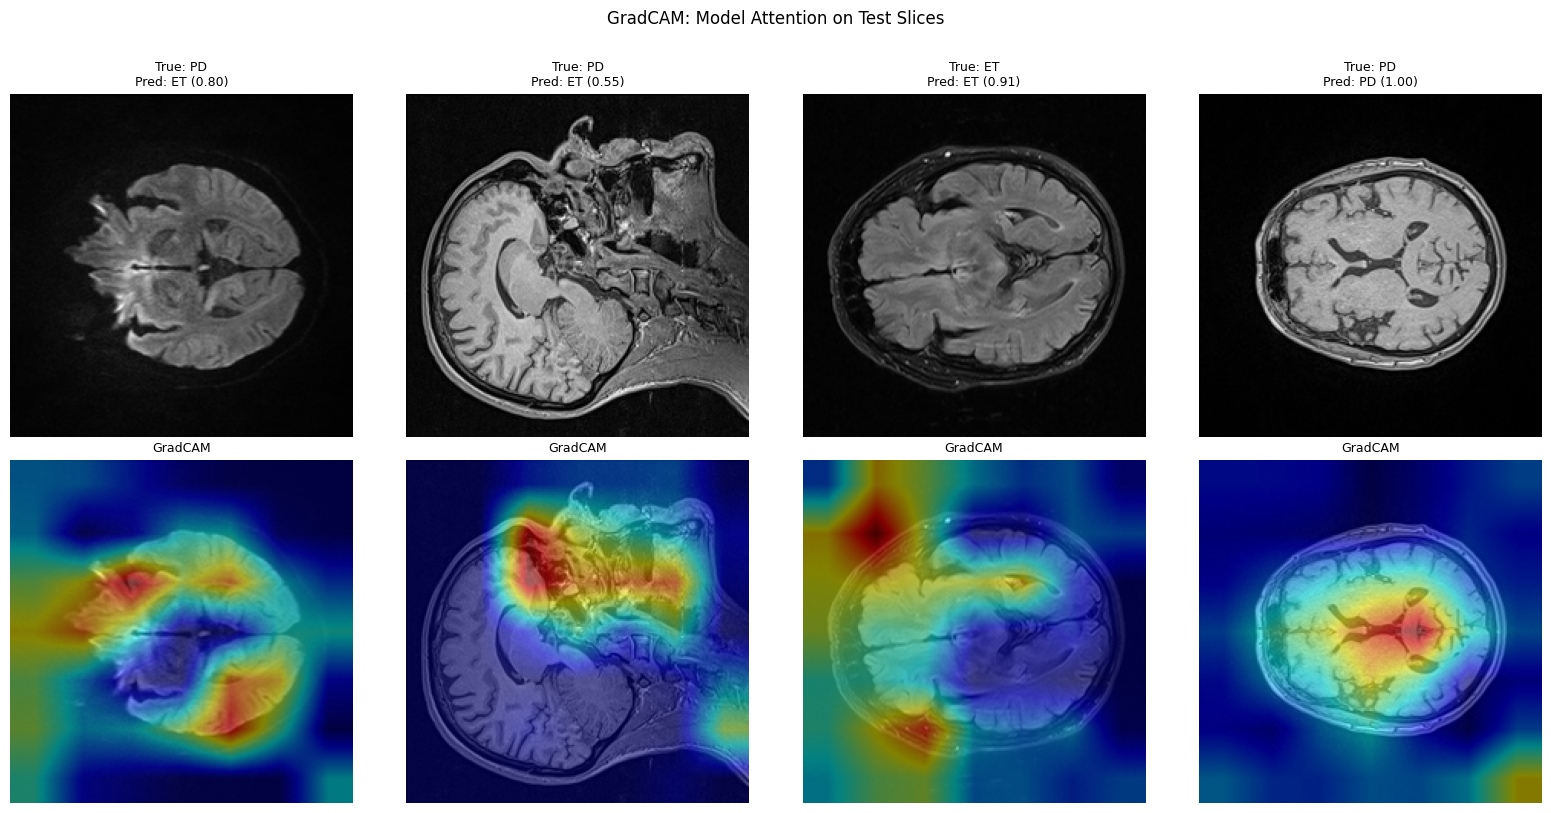

In [18]:
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

# Target the last convolutional block of EfficientNet-B0
# The internal structure: model._blocks[-1]
target_layers = [model._blocks[-1]] 

cam = GradCAM(model=model, target_layers=target_layers)

# Pick a few test samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_indices = random.sample(range(len(test_data)), 4)

for col, idx in enumerate(sample_indices):
    item = test_data[idx]

    img_dict = val_transforms(item)
    img_t = img_dict["image"].unsqueeze(0).to(DEVICE)

    label = item["label"]

    grayscale_cam = cam(input_tensor=img_t)[0]  # (H, W)

    # Prepare RGB image for overlay
    img_np = img_t[0, 0].detach().cpu().numpy()         # (H, W)
    img_rgb = np.stack([img_np] * 3, axis=-1)  # (H, W, 3)
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)

    overlay = show_cam_on_image(img_rgb.astype(np.float32), grayscale_cam, use_rgb=True)

    with torch.no_grad():
        probs = torch.softmax(model(img_t), dim=1).cpu().numpy()[0]
    pred = probs.argmax()

    axes[0, col].imshow(img_np, cmap="gray")
    axes[0, col].set_title(f"True: {CLASS_NAMES[label]}\nPred: {CLASS_NAMES[pred]} ({probs[pred]:.2f})", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title("GradCAM", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("GradCAM: Model Attention on Test Slices", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam.png"), dpi=150)
plt.show()